# K均值聚类

在本练习中，你将实现K均值算法，并将其用于图像压缩。   

* 你将从一个样本数据集开始，这将帮助你直观理解K均值算法的工作原理。
* 之后，你将使用K均值算法进行图像压缩，方法是将图像中出现的颜色数量减少到该图像中最常见的那些颜色。

# 大纲
- [1 - 实现K均值算法](#1)
    - [1.1 寻找最近的质心](#1.1)
        - [练习1](#ex01)
    - [1.2 计算质心均值](#1.2)
        - [练习2](#ex02)
- [2 - 样本数据集上的K均值算法](#2)
- [3 - 随机初始化](#3)
- [4 - 使用K均值算法进行图像压缩](#4)
    - [4.1 数据集](#4.1)
    - [4.2 对图像像素应用K均值算法](#4.2)
    - [4.3 压缩图像](#4.3)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

%matplotlib widget

<a name="1"></a>
## 1 - 实现K均值算法
K均值算法是一种自动将相似数据点聚类在一起的方法。   
* 具体来说，给定一个训练集$\{x^{(1)}, ..., x^{(m)}\}$，你希望将这些数据分组为几个紧密的“簇”。

* K均值算法是一个迭代过程，它
    * 从猜测初始质心开始，然后
    * 通过以下方式优化这个猜测：
        * 反复将样本分配到距离它们最近的质心，然后
        * 根据分配结果重新计算质心。

* 用伪代码表示，K均值算法如下：

    ``` python
    # 初始化质心
    # K是簇的数量
    centroids = kMeans_init_centroids(X, K)
    
    for iter in range(iterations):
        # 簇分配步骤：
        # 将每个数据点分配到最近的质心。 
        # idx[i] 对应质心的索引
        # 分配示例i
        idx = find_closest_centroids(X, centroids)

        # 移动质心: 
        # 根据簇分配计算新的质心
        centroids = compute_means(X, idx, K)
    ```


* 该算法的内循环反复执行两个步骤：
    * （i）将每个训练样本$x^{(i)}$分配到距离它最近的质心，以及
    * （ii）使用分配给每个质心的点重新计算该质心的均值。

    
* K均值算法总会收敛到质心的某个最终均值集合。


    
* 然而，收敛的解不一定总是理想的，这取决于质心的初始设置。
    * 因此，在实践中，K均值算法通常会使用不同的随机初始化多次运行。
    * 从不同随机初始化得到的这些不同解中进行选择的一种方法是，选择具有最低代价函数值（失真度）的那个解。  
    

在接下来的部分，你将分别实现K均值算法的两个阶段。
* 你将从完成`find_closest_centroid`开始，然后继续完成`compute_centroids`。 

<a name="1.1"></a>
### 1.1 寻找最近的质心   

在K均值算法的“聚类分配”阶段，给定质心的当前位置，该算法会将每个训练样本$x^{(i)}$分配到其最近的质心。

<a name="ex01"></a>
### 练习1
你的任务是完成`find_closest_centroids`中的代码。 
* 此函数接收数据矩阵`X`以及`centroids`中所有质心的位置。
* 它应输出一个一维数组`idx`（其元素数量与`X`相同），该数组保存每个训练样本最近质心的索引（取值范围为$\{1,...,K\}$，其中$K$是质心的总数）。
* 具体来说，对于每个样本$x^{(i)}$，我们设置 
$$c^{(i)} := j \quad \mathrm{that \; minimizes} \quad ||x^{(i)} - \mu_j||^2,$$
其中 
* $c^{(i)}$ 是距离 $x^{(i)}$ 最近的质心的索引（对应起始代码中的 `idx[i]`），并且
* $\mu_j$ 是第 $j$ 个质心的位置（值）。（存储在起始代码的 `centroids` 中）   

如果你遇到困难，可以查看下面单元格之后给出的提示，以帮助你完成实现。

In [2]:
# UNQ_C1
# GRADED FUNCTION: find_closest_centroids

def find_closest_centroids(X, centroids):
    """
    Computes the centroid memberships for every example
    
    Args:
        X (ndarray): (m, n) Input values      
        centroids (ndarray): k centroids
    
    Returns:
        idx (array_like): (m,) closest centroids
    
    """

    # Set K
    K = centroids.shape[0]

    # You need to return the following variables correctly
    idx = np.zeros(X.shape[0], dtype=int)

    ### START CODE HERE ###
    for i in range(X.shape[0]):
        distance = [] 
        for j in range(centroids.shape[0]):
            norm_ij = np.linalg.norm(X[i] - centroids[j])
            distance.append(norm_ij)
        
        idx[i] = np.argmin(distance)
    ### END CODE HERE ###
    
    return idx

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
    
* Here's how you can structure the overall implementation for this function
    ```python 
    def find_closest_centroids(X, centroids):
    
        # Set K
        K = centroids.shape[0]
    
        # You need to return the following variables correctly
        idx = np.zeros(X.shape[0], dtype=int)
    
        ### START CODE HERE ###
        for i in range(X.shape[0]):
            # Array to hold distance between X[i] and each centroids[j]
            distance = [] 
            for j in range(centroids.shape[0]):
                norm_ij = # Your code to calculate the norm between (X[i] - centroids[j])
                distance.append(norm_ij)
            
            idx[i] = # Your code here to calculate index of minimum value in distance
        ### END CODE HERE ###
        return idx
    ```
  
    If you're still stuck, you can check the hints presented below to figure out how to calculate `norm_ij` and `idx[i]`.
    
    <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate norm_ij</b></font></summary>
           &emsp; &emsp; You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html">np.linalg.norm</a> to calculate the norm 
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate norm_ij</b></font></summary>
               &emsp; &emsp; You can compute norm_ij as <code>norm_ij = np.linalg.norm(X[i] - centroids[j]) </code>
           </details>
    </details>

     <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate idx[i]</b></font></summary>
          &emsp; &emsp; You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.argmin.html">np.argmin</a> to find the index of the minimum value
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate idx[i]</b></font></summary>
              &emsp; &emsp; You can compute idx[i] as <code>idx[i] = np.argmin(distance)</code>
          </details>
    </details>
        
    </details>

</details>

    


现在让我们使用一个示例数据集来检查你的实现情况

In [3]:
# Load an example dataset that we will be using
X = load_data()

下面的代码将打印变量`X`中的前五个元素以及该变量的维度

In [4]:
print("First five elements of X are:\n", X[:5]) 
print('The shape of X is:', X.shape)

First five elements of X are:
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]
The shape of X is: (300, 2)


In [5]:
# Select an initial set of centroids (3 Centroids)
initial_centroids = np.array([[3,3], [6,2], [8,5]])

# Find closest centroids using initial_centroids
idx = find_closest_centroids(X, initial_centroids)

# Print closest centroids for the first three elements
print("First three elements in idx are:", idx[:3])

# UNIT TEST
from public_tests import *

find_closest_centroids_test(find_closest_centroids)


First three elements in idx are: [0 2 1]
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td> <b>First three elements in idx are<b></td>
    <td> [0 2 1] </td> 
  </tr>
</table>

<a name="1.2"></a>
### 1.2 计算质心均值
给定每个点到质心的分配，算法的第二阶段会为每个质心重新计算分配给它的点的均值。   

<a name="ex02"></a>
### 练习2
请完成下面的`compute_centroids`函数，以重新计算每个质心的值。
* 具体来说，对于每个质心$\mu_k$，我们设定
$$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x^{(i)}$$

    其中
* $C_k$ 是被分配到质心 $k$ 的样本集合
* $|C_k|$ 是集合 $C_k$ 中的样本数量

* 具体来说，如果有两个样本表明$x^{(3)}$ 和$x^{(5)}$被分配到质心$k = 2$，那么你应该更新$\mu_2 = \frac{1}{2}(x^{(3)}+x^{(5)})$。

如果你遇到困难，可以查看下面单元格之后给出的提示，以帮助你完成实现。

In [6]:
# UNQ_C2
# GRADED FUNCTION: compute_centpods

def compute_centroids(X, idx, K):
    """
    Returns the new centroids by computing the means of the 
    data points assigned to each centroid.
    
    Args:
        X (ndarray):   (m, n) Data points
        idx (ndarray): (m,) Array containing index of closest centroid for each 
                       example in X. Concretely, idx[i] contains the index of 
                       the centroid closest to example i
        K (int):       number of centroids
    
    Returns:
        centroids (ndarray): (K, n) New centroids computed
    """
    
    # Useful variables
    m, n = X.shape
    
    # You need to return the following variables correctly
    centroids = np.zeros((K, n))
    
    ### START CODE HERE ###
    for k in range(K):   
        points = X[idx == k]
        centroids[k] = np.mean(points, axis = 0)
    ### END CODE HERE ## 
    
    return centroids

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
    
* Here's how you can structure the overall implementation for this function
    ```python 
    def compute_centroids(X, idx, K):
        # Useful variables
        m, n = X.shape
    
        # You need to return the following variables correctly
        centroids = np.zeros((K, n))
    
        ### START CODE HERE ###
        for k in range(K):   
            points = # Your code here to get a list of all data points in X assigned to centroid k  
            centroids[k] = # Your code here to compute the mean of the points assigned
    ### END CODE HERE ## 
    
    return centroids
    ```
  
    If you're still stuck, you can check the hints presented below to figure out how to calculate `points` and `centroids[k]`.
    
    <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate points</b></font></summary>
           &emsp; &emsp; Say we wanted to find all the values in X that were assigned to cluster <code>k=0</code>. That is, the corresponding value in idx for these examples is 0. In Python, we can do it as <code>X[idx == 0]</code>. Similarly, the points assigned to centroid <code>k=1</code> are <code>X[idx == 1]</code>
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate points</b></font></summary>
               &emsp; &emsp; You can compute points as <code>points = X[idx == k] </code>
           </details>
    </details>

     <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate centroids[k]</b></font></summary>
          &emsp; &emsp; You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.mean.html">np.mean</a> to find the mean. Make sure to set the parameter <code>axis=0</code> 
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate centroids[k]</b></font></summary>
              &emsp; &emsp; You can compute centroids[k] as <code>centroids[k] = np.mean(points, axis = 0)</code>
          </details>
    </details>
        
    </details>

</details>

    


现在通过运行下面的单元格来检查你的实现情况

In [7]:
K = 3
centroids = compute_centroids(X, idx, K)

print("The centroids are:", centroids)

# UNIT TEST
compute_centroids_test(compute_centroids)


The centroids are: [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]
All tests passed!


**Expected Output**:

2.42830111 3.15792418

5.81350331 2.63365645

7.11938687 3.6166844 

<a name="2"></a>
## 2 - 对样本数据集执行K均值算法

在完成上述两个函数（`find_closest_centroids`和`compute_centroids`）后，下一步是在一个二维玩具数据集上运行K均值算法，以帮助你理解K均值算法的工作原理。
* 我们建议你查看下面的函数（`run_kMeans`），了解其工作原理。
* 请注意，代码会在循环中调用你实现的这两个函数。

当你运行下面的代码时，它将生成一个可视化结果，展示算法每次迭代的进展。
* 最后，你的图形应该与图1中显示的图形相似。

<img src="images/figure 1.png" width="500" height="500">

**注意**：此部分你无需实现任何内容。只需运行下面提供的代码。

In [8]:
# You do not need to implement anything for this part

def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    """
    Runs the K-Means algorithm on data matrix X, where each row of X
    is a single example
    """
    
    # Initialize values
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids    
    idx = np.zeros(m)
    
    # Run K-Means
    for i in range(max_iters):
        
        #Output progress
        print("K-Means iteration %d/%d" % (i, max_iters-1))
        
        # For each example in X, assign it to the closest centroid
        idx = find_closest_centroids(X, centroids)
        
        # Optionally plot progress
        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids
            
        # Given the memberships, compute new centroids
        centroids = compute_centroids(X, idx, K)
    plt.show() 
    return centroids, idx

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


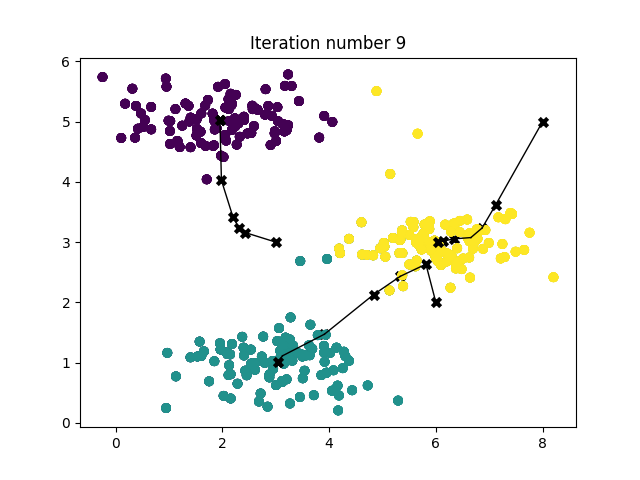

In [9]:
# Load an example dataset
X = load_data()

# Set initial centroids
initial_centroids = np.array([[3,3],[6,2],[8,5]])
K = 3

# Number of iterations
max_iters = 10

centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

<a name="3"></a>
### 3 - 随机初始化

示例数据集的质心初始分配经过设计，因此你将看到与图1相同的图形。在实践中，初始化质心的一个好策略是从训练集中随机选择示例。

在本部分练习中，你应该了解函数 `kMeans_init_centroids` 是如何实现的。
* 代码首先随机打乱示例的索引（使用 `np.random.permutation()`）。
* 然后，根据索引的随机排列选择前 $K$ 个示例。
    * 这使得可以随机选择示例，而不会有两次选择同一个示例的风险。
  
**注意**：在本部分练习中，你无需实现任何内容。

In [10]:
# You do not need to modify this part

def kMeans_init_centroids(X, K):
    """
    This function initializes K centroids that are to be 
    used in K-Means on the dataset X
    
    Args:
        X (ndarray): Data points 
        K (int):     number of centroids/clusters
    
    Returns:
        centroids (ndarray): Initialized centroids
    """
    
    # Randomly reorder the indices of examples
    randidx = np.random.permutation(X.shape[0])
    
    # Take the first K examples as centroids
    centroids = X[randidx[:K]]
    
    return centroids

<a name="4"></a>
## 4 - 利用K均值算法进行图像压缩

在本练习中，你将把K均值算法应用于图像压缩。   

* 在一种简单的24位图像颜色表示法中$^{2}$，每个像素由三个8位无符号整数（取值范围为0到255）表示，这些整数指定了红色、绿色和蓝色的强度值。这种编码方式通常被称为RGB编码。
* 我们的图像包含数千种颜色，在本练习的这一部分，你将把颜色数量减少到16种。
* 通过这种减少，就有可能以一种高效的方式表示（压缩）照片。
* 具体来说，你只需要存储所选16种颜色的RGB值，而对于图像中的每个像素，你现在只需要存储该位置颜色的索引（用4位就足以表示16种可能性）。

在这一部分，你将使用K均值算法来选择用于表示压缩图像的16种颜色。
* 具体而言，你将把原始图像中的每个像素视为一个数据样本，并使用K均值算法在三维RGB空间中找到最能对像素进行分组（聚类）的16种颜色。
* 一旦你计算出图像上的聚类中心，然后你将使用这16种颜色替换原始图像中的像素。 

<img src="images/figure 2.png" width="500" height="500">

$^{2}$<sub>本练习中使用的照片归弗兰克·沃特斯（Frank Wouters）所有，并经其许可使用。</sub>

<a name="4.1"></a>
### 4.1 数据集   

**加载图像**   

首先，你将使用`matplotlib`读取原始图像，如下所示。

In [11]:
# Load an image of a bird
original_img = plt.imread('bird_small.png')

**可视化图像**
你可以使用以下代码可视化刚刚加载的图像。

In [12]:
# Visualizing the image
plt.imshow(original_img)

**检查变量的维度**   

一如既往，你需要打印出变量的形状，以便更熟悉数据。

In [13]:
print("Shape of original_img is:", original_img.shape)

Shape of original_img is: (128, 128, 3)


如你所见，这会创建一个三维矩阵`original_img`，其中
* 前两个索引确定像素位置，并且
* 第三个索引代表红色、绿色或蓝色。

例如，`original_img[50, 33, 2]`给出第50行、第33列像素的蓝色强度。   

#### 处理数据   

要调用`run_kMeans`，你首先需要将矩阵`original_img`转换为二维矩阵。   

* 下面的代码重塑矩阵`original_img`，以创建一个$m \times 3$的像素颜色矩阵（其中
$m = 16384 = 128\times128$）

In [14]:
# 除以255，以便所有值都在0到1的范围内
original_img = original_img / 255

# Reshape the image into an m x 3 matrix where m = number of pixels
# (in this case m = 128 x 128 = 16384)
# Each row will contain the Red, Green and Blue pixel values
# This gives us our dataset matrix X_img that we will use K-Means on.

X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))

<a name="4.2"></a>
### 4.2 图像像素上的K均值算法   

现在，运行下面的代码块，对预处理后的图像运行K均值算法。

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


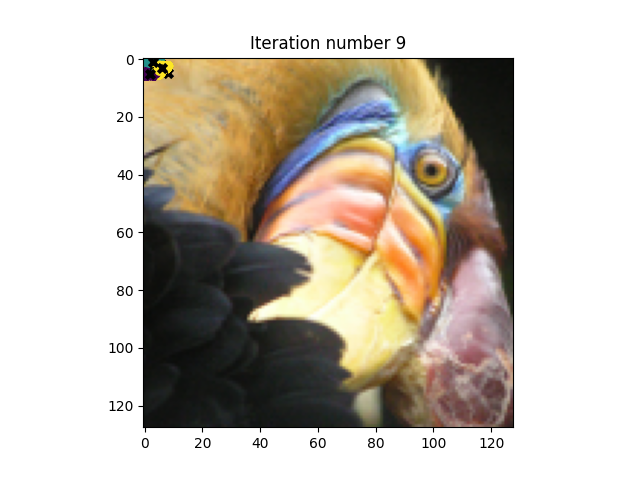

In [15]:
# 在这些数据上运行你的K均值算法
# You should try different values of K and max_iters here
K = 16                       
max_iters = 10               

# Using the function you have implemented above. 
initial_centroids = kMeans_init_centroids(X_img, K) 

# Run K-Means - this takes a couple of minutes
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters) 

In [16]:
print("Shape of idx:", idx.shape)
print("Closest centroid for the first five elements:", idx[:5])

Shape of idx: (16384,)
Closest centroid for the first five elements: [8 8 8 8 8]


<a name="4.3"></a>
### 4.3 压缩图像

在找到代表图像的前$K = 16$种颜色后，现在你可以使用`find_closest_centroids`函数将每个像素位置分配给与其最接近的质心。
* 这使你能够通过每个像素的质心分配来表示原始图像。
* 请注意，你已经显著减少了描述图像所需的位数。
  * 原始图像中每个$128×128$像素位置需要24位，因此总大小为$128×128×24 = 393216$位。
  * 新的表示形式需要一些额外的存储，即一个包含16种颜色的字典，每种颜色需要24位，但图像本身每个像素位置仅需4位。
  * 因此，最终使用的位数为$16×24 + 128×128×4 = 65920$位，这相当于将原始图像压缩了约6倍。 

In [17]:
# Represent image in terms of indices
X_recovered = centroids[idx, :] 

# Reshape recovered image into proper dimensions
X_recovered = np.reshape(X_recovered, original_img.shape) 

最后，你可以通过仅基于质心分配来重建图像，从而查看压缩效果。
* 具体来说，你可以用分配给它的质心的平均值替换每个像素位置。
* 图3展示了我们得到的重建结果。尽管生成的图像保留了原始图像的大部分特征，但我们也看到了一些压缩失真。 

<img src="images/figure 3.png" width="700" height="700">


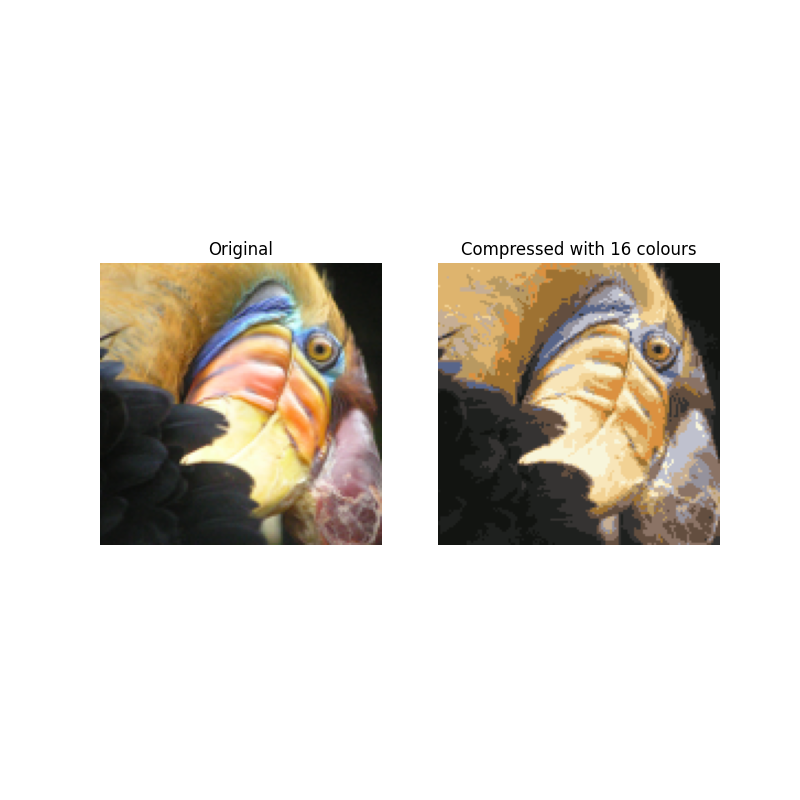

In [18]:
# Display original image
fig, ax = plt.subplots(1,2, figsize=(8,8))
plt.axis('off')

ax[0].imshow(original_img*255)
ax[0].set_title('Original')
ax[0].set_axis_off()


# Display compressed image
ax[1].imshow(X_recovered*255)
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()

plt.show()